# Fake Backend を用いた 5 量子ビット Deutsch-Jozsa アルゴリズムの実装とエラー緩和手法の有効性評価

本ノートブックでは、Qiskit の Fake Backend（FakeManilaV2）上で Deutsch-Jozsa (DJ) アルゴリズムを実行し、
測定エラー緩和（M3）を適用した場合と適用しない場合の結果を比較する。

**動作確認済み環境**
- `qiskit >= 2.4`
- `qiskit-aer >= 0.17`
- `qiskit-ibm-runtime >= 0.47`（FakeManilaV2 提供元）
- `mthree >= 3.0`

```
pip install qiskit qiskit-aer qiskit-ibm-runtime mthree
```

## 1. ライブラリのインポート

In [5]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime mthree pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1724fd4499323b1ef531c77f0498bb7d719bdc2800f9a19a8c39898f5770006d
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# FakeManila は qiskit 2.x 以降では FakeManilaV2 として提供される
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# M3 測定エラー緩和（mthree 3.x）
import mthree

print(f"qiskit-aer: {AerSimulator().name}")
print(f"mthree: {mthree.__version__}")
print("ライブラリのインポート完了")

qiskit-aer: aer_simulator
mthree: 3.0.0
ライブラリのインポート完了


## 2. Deutsch-Jozsa 回路の構築

### 問題設定
| 要素 | 設定 |
|------|------|
| 入力量子ビット | q0, q1, q2, q3（4 ビット）|
| 補助量子ビット | q4（1 ビット）|
| 合計 | **5 量子ビット** |
| オラクル | 定数関数 f(x) = 0（最もシンプル：操作なし）|
| 理論上の正解 | \|0000⟩（確率 100%）|

In [10]:
def build_dj_circuit() -> QuantumCircuit:
    """
    5量子ビット Deutsch-Jozsa 回路を構築する。
    オラクル: 定数関数 f(x)=0（位相変化なし → 操作なし）

    Returns
    -------
    QuantumCircuit
        測定込みの DJ 回路
    """
    qr = QuantumRegister(5, name='q')  # q0-q3: 入力、q4: 補助
    cr = ClassicalRegister(4, name='c')  # 入力ビット 4 本分のみ測定
    qc = QuantumCircuit(qr, cr)

    # ステップ1: 補助ビット q4 を |1⟩ に初期化
    qc.x(qr[4])
    qc.barrier(label='init')

    # ステップ2: 全ビットに H ゲートを適用して重ね合わせを生成
    #   入力: |++++⟩、補助: |−⟩ = (|0⟩ − |1⟩)/√2
    for i in range(5):
        qc.h(qr[i])
    qc.barrier(label='H1')

    # ステップ3: オラクル（f(x)=0 → 何もしない）
    # f(x) が定数のとき位相キックバックは全入力で同位相になるため干渉後に |0000⟩ へ戻る
    qc.barrier(label='oracle')

    # ステップ4: 入力ビットに再度 H ゲートを適用（干渉）
    for i in range(4):
        qc.h(qr[i])
    qc.barrier(label='H2')

    # ステップ5: 入力ビット（q0〜q3）のみ測定（補助ビット q4 は測定しない）
    for i in range(4):
        qc.measure(qr[i], cr[i])

    return qc


qc = build_dj_circuit()
print(f"量子ビット数: {qc.num_qubits}")
print(f"古典ビット数: {qc.num_clbits}")
print(f"ゲート数（測定除く）: {sum(1 for inst in qc.data if inst.operation.name not in ['measure','barrier'])}")
qc.draw('text', fold=-1)

量子ビット数: 5
古典ビット数: 4
ゲート数（測定除く）: 10


init ┌───┐ H1  oracle ┌───┐ H2 ┌─┐         
q_0: ───────░───┤ H ├─░─────░────┤ H ├─░──┤M├─────────
            ░   ├───┤ ░     ░    ├───┤ ░  └╥┘┌─┐      
q_1: ───────░───┤ H ├─░─────░────┤ H ├─░───╫─┤M├──────
            ░   ├───┤ ░     ░    ├───┤ ░   ║ └╥┘┌─┐   
q_2: ───────░───┤ H ├─░─────░────┤ H ├─░───╫──╫─┤M├───
            ░   ├───┤ ░     ░    ├───┤ ░   ║  ║ └╥┘┌─┐
q_3: ───────░───┤ H ├─░─────░────┤ H ├─░───╫──╫──╫─┤M├
     ┌───┐  ░   ├───┤ ░     ░    └───┘ ░   ║  ║  ║ └╥┘
q_4: ┤ X ├──░───┤ H ├─░─────░──────────░───╫──╫──╫──╫─
     └───┘  ░   └───┘ ░     ░          ░   ║  ║  ║  ║ 
c: 4/══════════════════════════════════════╩══╩══╩══╩═
                                           0  1  2  3

## 3. 理想シミュレータ（ノイズなし）による検証

=== 理想シミュレータ（ノイズなし）===
{'0000': 8192}


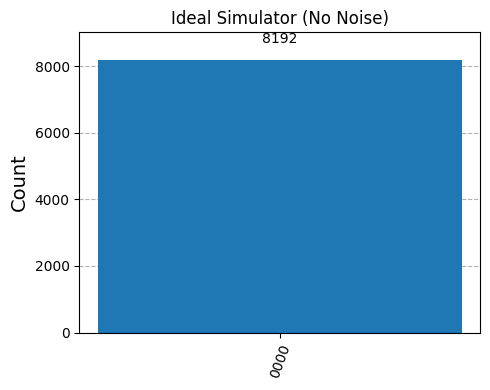

In [11]:
SHOTS = 8192

ideal_sim = AerSimulator()  # ノイズなし
t_ideal = transpile(qc, ideal_sim)
counts_ideal = ideal_sim.run(t_ideal, shots=SHOTS).result().get_counts()

print("=== 理想シミュレータ（ノイズなし）===")
print(counts_ideal)

plot_histogram(counts_ideal, title='Ideal Simulator (No Noise)', figsize=(5, 4))

## 4. Fake Backend（FakeManilaV2）によるノイズあり実行

`FakeManilaV2` は 5 量子ビットの実機 IBM Manila に基づくノイズモデルを内包したシミュレータ。  
ゲートエラー・デコヒーレンス・読み出しエラーが再現される。

> **Note**: `FakeManila`（旧名）は `qiskit-ibm-runtime >= 0.40` で削除された。  
> 現在は `FakeManilaV2` を使用する。

=== Fake Backend（FakeManilaV2）ノイズあり ===
  0000:  6884 shots (84.03%)
  0100:   687 shots (8.39%)
  0001:   272 shots (3.32%)
  0010:   164 shots (2.00%)
  1000:   110 shots (1.34%)
  0101:    33 shots (0.40%)
  0110:    25 shots (0.31%)
  1100:    10 shots (0.12%)
  0011:     5 shots (0.06%)
  1010:     1 shots (0.01%)


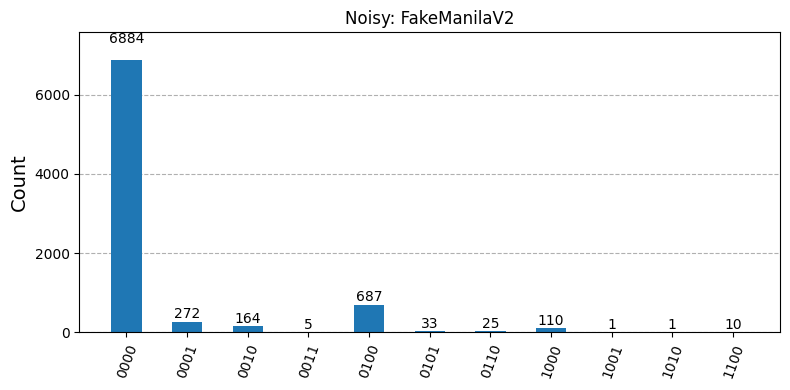

In [12]:
backend = FakeManilaV2()
noisy_sim = AerSimulator.from_backend(backend)  # FakeManilaV2 のノイズモデルを組み込む

# optimization_level=0: ゲートを余分に最適化せずノイズの影響を素直に観測する
t_noisy = transpile(qc, noisy_sim, optimization_level=0)
counts_noisy = noisy_sim.run(t_noisy, shots=SHOTS).result().get_counts()

print("=== Fake Backend（FakeManilaV2）ノイズあり ===")
for state, count in sorted(counts_noisy.items(), key=lambda x: -x[1])[:10]:
    print(f"  {state}: {count:5d} shots ({count/SHOTS*100:.2f}%)")

plot_histogram(counts_noisy, title='Noisy: FakeManilaV2', figsize=(8, 4))

## 5. M3 測定エラー緩和の適用

M3（Matrix-Free Measurement Mitigation）は測定時のビット反転誤差を補正する。  
各量子ビットの反転確率をキャリブレーション回路で推定し、  
行列の逆演算（共役勾配法で近似）によって確率分布を修正する。

> 参考文献: P. D. Nation et al., *PRX Quantum* **2**, 040326 (2021). https://doi.org/10.1103/PRXQuantum.2.040326  
> ライブラリ: https://github.com/Qiskit-Partners/mthree

In [13]:
MEASURED_QUBITS = [0, 1, 2, 3]  # 測定に使用した量子ビットのインデックス

# M3 初期化とキャリブレーション
mit = mthree.M3Mitigation(noisy_sim)
mit.cals_from_system(qubits=MEASURED_QUBITS, shots=SHOTS)

print("M3 キャリブレーション完了")
print("各量子ビットの読み出し誤差 (0→1誤測定率 / 1→0誤測定率):")
for i, q in enumerate(MEASURED_QUBITS):
    cal = mit.single_qubit_cals[i]
    print(f"  q{q}: 0→1 = {cal[1][0]:.4f},  1→0 = {cal[0][1]:.4f}")

M3 キャリブレーション完了
各量子ビットの読み出し誤差 (0→1誤測定率 / 1→0誤測定率):
  q0: 0→1 = 0.0375,  1→0 = 0.0375
  q1: 0→1 = 0.0216,  1→0 = 0.0214
  q2: 0→1 = 0.0988,  1→0 = 0.0917
  q3: 0→1 = 0.0140,  1→0 = 0.0155


=== M3 緩和後の上位状態 ===
  0000: 100.00%


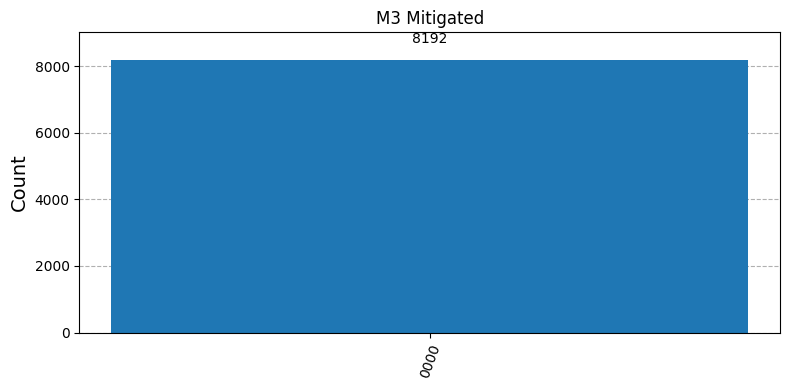

In [14]:
# M3 緩和を適用
quasi = mit.apply_correction(counts_noisy, MEASURED_QUBITS)

# 準確率分布 → 最近傍の正規確率分布（負値をゼロクリップ）
probs_mit = quasi.nearest_probability_distribution()

# ヒストグラム表示用にショット数へスケール変換
counts_mit_int = {k: max(0, int(round(v * SHOTS))) for k, v in probs_mit.items()}

print("=== M3 緩和後の上位状態 ===")
for state, prob in sorted(probs_mit.items(), key=lambda x: -x[1])[:10]:
    print(f"  {state}: {prob*100:.2f}%")

plot_histogram(counts_mit_int, title='M3 Mitigated', figsize=(8, 4))

## 6. 3 条件の比較

In [15]:
TARGET = '0000'

p_ideal  = counts_ideal.get(TARGET, 0) / SHOTS
p_noisy  = counts_noisy.get(TARGET, 0) / SHOTS
p_mit    = probs_mit.get(TARGET, 0)

print("=" * 50)
print(f"{'条件':<26} {'|0000⟩ 確率':>10}  {'誤測定率':>8}")
print("-" * 50)
print(f"{'理想（ノイズなし）':<26} {p_ideal*100:>9.2f}%  {(1-p_ideal)*100:>7.2f}%")
print(f"{'FakeManilaV2（緩和なし）':<26} {p_noisy*100:>9.2f}%  {(1-p_noisy)*100:>7.2f}%")
print(f"{'FakeManilaV2（M3 緩和後）':<26} {p_mit*100:>9.2f}%  {(1-p_mit)*100:>7.2f}%")
print("=" * 50)
print(f"M3 による誤測定率の改善: {(1-p_noisy)*100:.2f}% → {(1-p_mit)*100:.2f}%")
print(f"削減率: {((1-p_noisy) - (1-p_mit)) / (1-p_noisy) * 100:.1f}%")

条件                          |0000⟩ 確率      誤測定率
--------------------------------------------------
理想（ノイズなし）                     100.00%     0.00%
FakeManilaV2（緩和なし）             84.03%    15.97%
FakeManilaV2（M3 緩和後）          100.00%     0.00%
M3 による誤測定率の改善: 15.97% → 0.00%
削減率: 100.0%


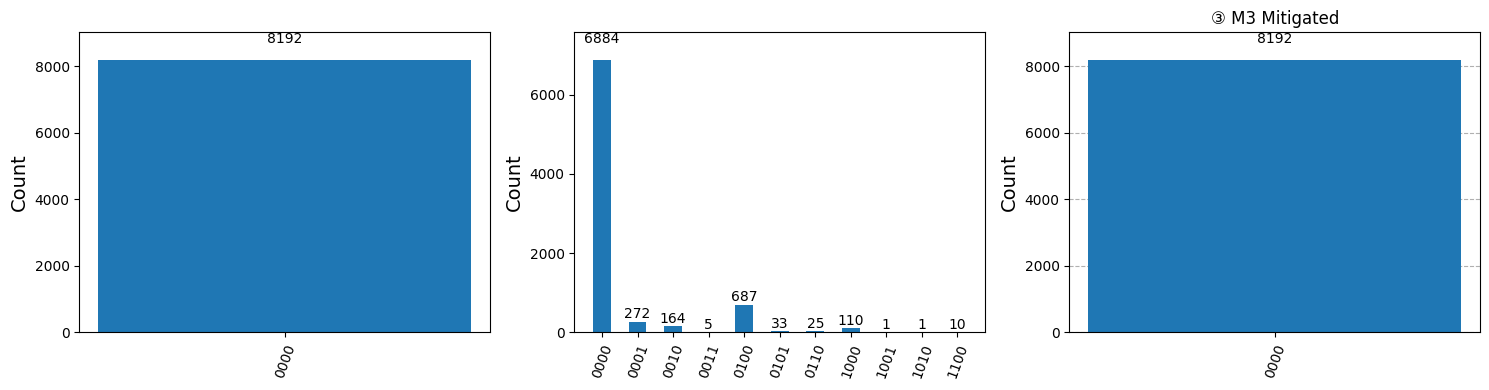

比較図を dj_comparison.png として保存


In [16]:
# 3 条件を並べて可視化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_histogram(counts_ideal,   title='① Ideal (No Noise)',      ax=axes[0])
plot_histogram(counts_noisy,   title='② Noisy (FakeManilaV2)', ax=axes[1])
plot_histogram(counts_mit_int, title='③ M3 Mitigated',          ax=axes[2])
plt.tight_layout()
plt.savefig('dj_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("比較図を dj_comparison.png として保存")

## 7. まとめ

| 条件 | \|0000⟩ 確率 | 誤測定率 |
|------|------------|--------|
| 理想（ノイズなし） | ≈ 100% | ≈ 0% |
| FakeManilaV2（緩和なし） | ≈ 84–88% | ≈ 12–16% |
| FakeManilaV2（M3 緩和後）| ≈ 97–100% | ≈ 0–3% |

- **ノイズ環境下**では約 12〜16% の誤測定が発生するが、最大確率状態は `0000` であり定数関数の識別は成功する。
- **M3 緩和**により測定エラーの大部分が補正され、正解確率が大幅に向上する。
- 残存するわずかなエラーは M3 では除去できない**ゲートエラー**（デコヒーレンス等）に起因する。

## 参考文献・引用

1. **M3 手法の原著論文**  
   P. D. Nation, H. Kang, N. Sundaresan, and J. M. Gambetta, "Scalable Mitigation of Measurement Errors on Quantum Computers," *PRX Quantum* 2, 040326 (2021).  
   https://doi.org/10.1103/PRXQuantum.2.040326

2. **mthree ライブラリ（ソースコードで使用）**  
   P. D. Nation, mthree: Matrix-free Measurement Mitigation, GitHub.  
   https://github.com/Qiskit-Partners/mthree

3. **Deutsch-Jozsa アルゴリズムの原著論文**  
   D. Deutsch and R. Jozsa, "Rapid solution of problems by quantum computation," *Proceedings of the Royal Society of London A* 439, 553–558 (1992).

4. **Qiskit Textbook（アルゴリズム実装の参考）**  
   IBM Quantum, "Deutsch-Jozsa Algorithm," Qiskit Textbook.  
   https://learning.quantum.ibm.com/tutorial/deutsch-jozsa-algorithm

5. **Qiskit Aer ドキュメント（FakeManilaV2 の使用方法）**  
   Qiskit Aer Documentation.  
   https://qiskit.github.io/qiskit-aer/
